### Imports and setup

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import cv2

import weyl

### Base code

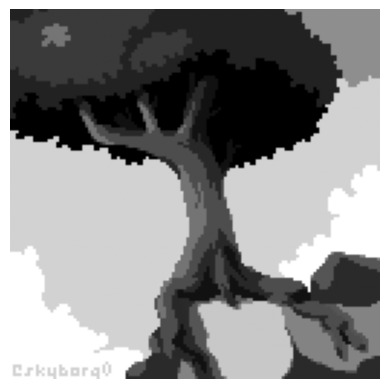

In [12]:
base_image = cv2.imread('datasets/tests_images/tree.png', cv2.IMREAD_GRAYSCALE) / 255.0
base_image = cv2.resize(base_image, dsize=(128, 128), interpolation=cv2.INTER_CUBIC)
plt.axis('off')
plt.imshow(base_image, cmap='gray')
plt.show()

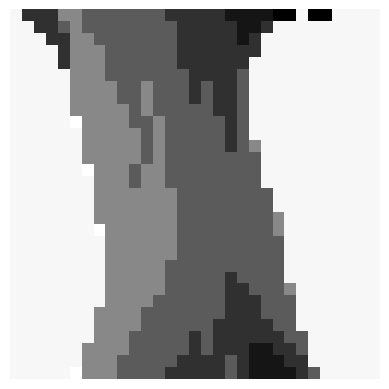

In [13]:
part_image = base_image[54:85, 54:85]
plt.axis('off')
plt.imshow(part_image, cmap='gray')
plt.show()

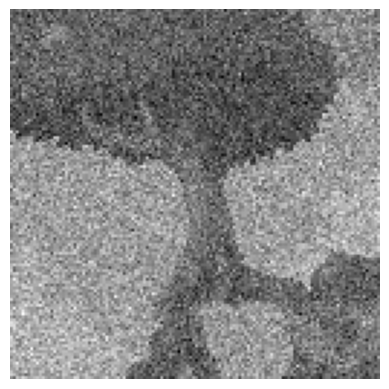

In [14]:
np.random.seed(42)
noised_image = np.random.normal(base_image, 0.2)
plt.axis('off')
plt.imshow(noised_image, cmap='gray')
plt.show()

In [15]:
diff_image_optimized = weyl.PatternMatching(part_image, noised_image, weyl.WeylOptimized)
plt.axis('off')
plt.imshow(diff_image_optimized, cmap='gray')
plt.show()

TypeError: 'module' object is not callable. Did you mean: 'tqdm.tqdm(...)'?

100%|██████████| 128/128 [04:07<00:00,  1.93s/it]

------------------------------------------------------------------
Total execution time        : 247.43810153007507 seconds
Average row execution time  : 1.9331101682037115 seconds
Average cell execution time : 0.015102423189091496 seconds
------------------------------------------------------------------


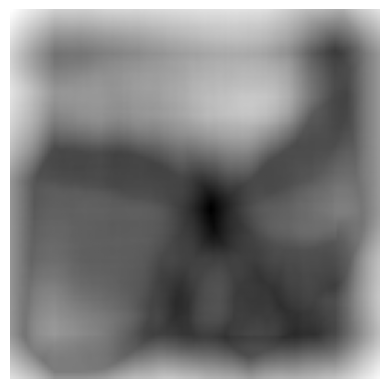

In [ ]:
diff_image_naive = weyl.PatternMatching(part_image, noised_image, weyl.WeylNaive)
plt.axis('off')
plt.imshow(diff_image_naive, cmap='gray')
plt.show()

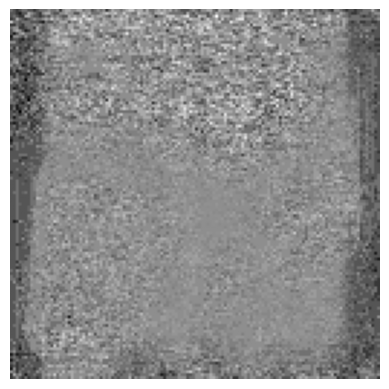

In [ ]:
models_variation = diff_image_naive - diff_image_optimized
plt.axis('off')
plt.imshow(models_variation, cmap='gray')
plt.show()

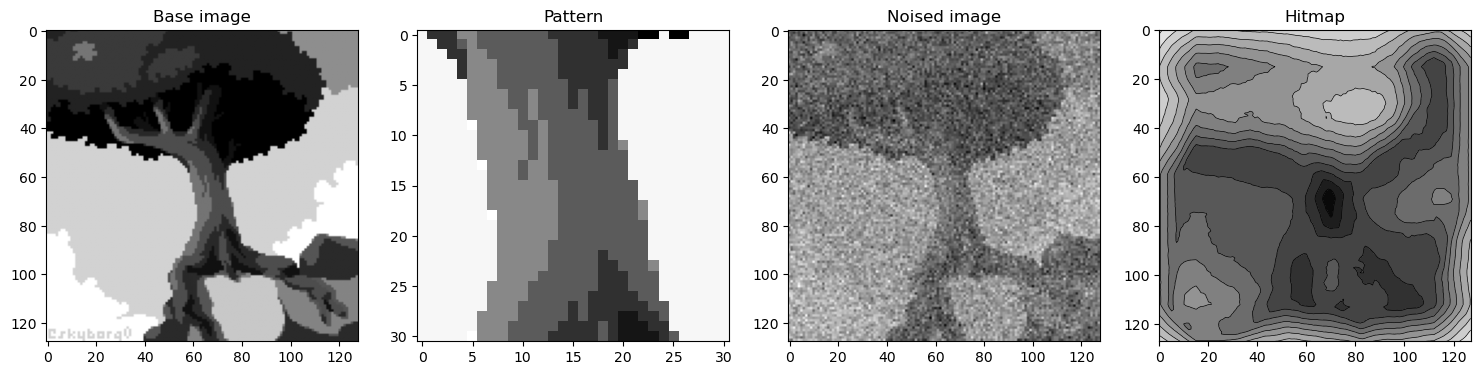

In [ ]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 15))

ax1.imshow(base_image, cmap='gray')
ax1.set_title("Base image")

ax2.imshow(part_image, cmap='gray')
ax2.set_title("Pattern")

ax3.imshow(noised_image, cmap='gray')
ax3.set_title("Noised image")

ax4.contourf(diff_image_optimized, levels=12, cmap='gray')
ax4.contour(diff_image_optimized, levels=12, colors='black', linewidths=0.5)
ax4.set_aspect('equal')
ax4.invert_yaxis()
ax4.set_title("Hitmap")

plt.tight_layout()
plt.show()

In [ ]:
position_found = np.unravel_index(diff_image_optimized.argmin(), diff_image_optimized.shape)
print(f"Found at position : {position_found}")

Found at position : (np.int64(69), np.int64(69))


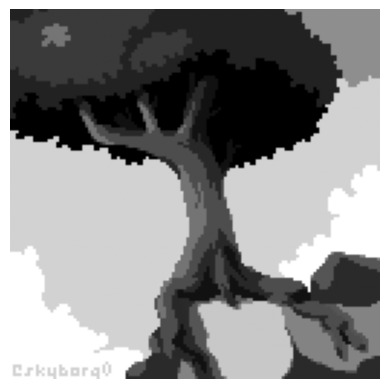

In [ ]:
new_image = base_image.copy()
new_image[54:85, 54:85] = 0.0

px, py = position_found
new_image[px - 15:px + 15 + 1, py - 15:py + 15 + 1] = part_image
plt.axis('off')
plt.imshow(new_image, cmap='gray')
plt.show()

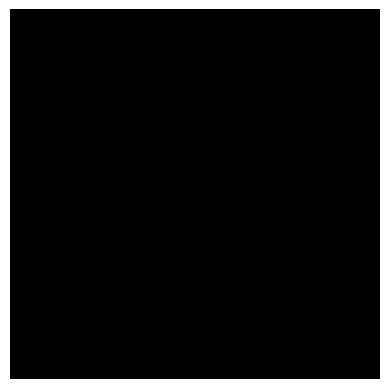

In [ ]:
final_diff_image = base_image - new_image
plt.axis('off')
plt.imshow(final_diff_image, cmap='gray')
plt.show()